EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master_df = pd.read_csv('master_df_19Feb 25988.csv')

master_df.head()

,city_id,country_name_oa,country_name_wb,iso_code,iso_country_3,city_lat,city_lon,city_pop,city_tier,city_name,...,nearest_airport_lon,nearest_airport_elev_m,nearest_runway_length_m,nearest_runway_width_m,nearest_runway_area_km2,country_GDP($b),country_GDPcap($000s),country_pop(m),country_popden_persqkm,air_passengers(m)
0,3367877,South Africa,South Africa,ZA,ZAF,-33.91075,19.11980,20000,Tier 4,Franschhoek,...,18.822327,89.9160,759.5616,29.8704,0.022688,381.440724,6.034272,63.212384,52.108569,15.454596
1,4714149,United States,United States,US,USA,30.15522,-95.21132,20000,Tier 4,New Caney,...,-95.341400,29.5656,3657.9048,45.7200,0.167239,27292.170793,81.032262,336.806231,36.819806,941.557000
2,6162703,Canada,Canada,CA,CAN,45.49389,-75.58833,20000,Tier 4,Templeton-Est,...,-75.563599,64.3128,1828.8000,45.7200,0.083613,2173.339670,54.220329,40.083484,4.560798,88.618000
3,12625526,Malaysia,Malaysia,MY,MYS,3.14165,101.59089,20000,Tier 4,Tropicana Indah,...,101.549004,27.4320,3779.8248,45.1104,0.170509,399.949419,11.386040,35.126298,106.913097,46.698381
4,2645420,United Kingdom,United Kingdom,GB,GBR,52.49755,-2.16889,20000,Tier 4,Kingswinford,...,-2.259440,86.2584,1182.0144,29.8704,0.035307,3420.796654,49.944470,68.492000,283.106684,118.945920


In [ ]:
master_df.shape

(25988, 27)

In [ ]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25988 entries, 0 to 25987
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   city_id                     25988 non-null  int64  
 1   country_name_oa             25988 non-null  object 
 2   country_name_wb             25988 non-null  object 
 3   iso_code                    25971 non-null  object 
 4   iso_country_3               25988 non-null  object 
 5   city_lat                    25988 non-null  float64
 6   city_lon                    25988 non-null  float64
 7   city_pop                    25988 non-null  int64  
 8   city_tier                   25988 non-null  object 
 9   city_name                   25988 non-null  object 
 10  city_avg_temp               25988 non-null  float64
 11  city_max_temp               25988 non-null  float64
 12  nearest_airport_type        25988 non-null  object 
 13  nearest_airport_name        259

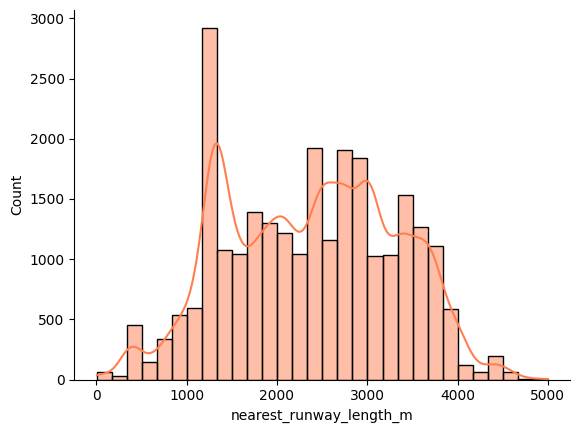

In [ ]:
#A. Distribution of Key Variables

#Histogram of y Target Variable
plt.subplotsfigsize=(16, 6)
sns.histplot(master_df['nearest_runway_length_m'].dropna(), bins=30, kde=True, color='coral')
sns.despine()
plt.show()

In [ ]:
#Finding the median, mean and max of 'nearest runway length'

print(master_df['nearest_runway_length_m'].median())
print(master_df['nearest_runway_length_m'].mean())
print(master_df['nearest_runway_length_m'].max())

2439.924
2375.665170917826
4999.9392


We can see that the target y variable is generally normally distributed. There seems to be 2 peaks - 1 clustered around 3000m, and 1 around 1500m or so. This is quite consistent with the presence of large 'hub' airports and smaller 'spoke' airports that exists generally in the world of airport categorisation. Smaller, regional airports serve smaller narrow-body aircraft which do not need as long runways as wide-body aircraft. Such smaller aircraft feed (like spokes) fly into larger hubs that then agglomerate passenger numbers into larger aircraft that serve longer routes across the world

It must be highlighted that 18% of runway lengths were imputed earlier during the data cleaning stage (~1700 / ~ 9500) with the means of each airport type (small, medium, large, helipads)

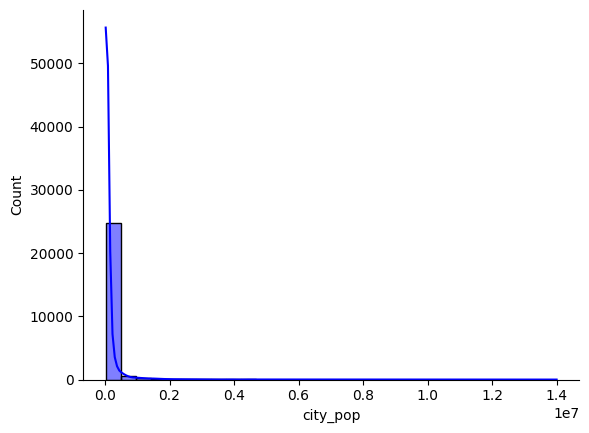

In [ ]:
#Histogram of City Population

plt.subplotsfigsize=(16, 6)
sns.histplot(master_df['city_pop'].dropna(), bins=30, kde=True, color='blue')
sns.despine()
plt.show()

A histogram of city population shows an extremely left-skewed data shape. Using a logarithmic transformation would be better for visualising the spread

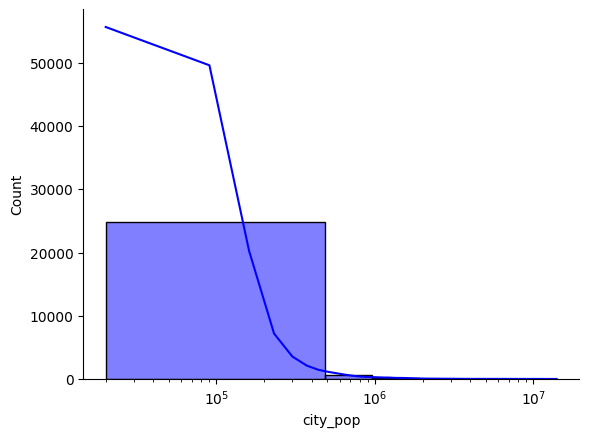

In [ ]:
#Histogram of City Population (Log scaled)

plt.subplotsfigsize=(16, 6)
sns.histplot(master_df['city_pop'].dropna(), bins=30, kde=True, color='blue')
sns.despine()
plt.xscale('log')
plt.show()

This graph supports city growth trends - that is, larger cities tend to get larger and larger, at the expense of smaller cities

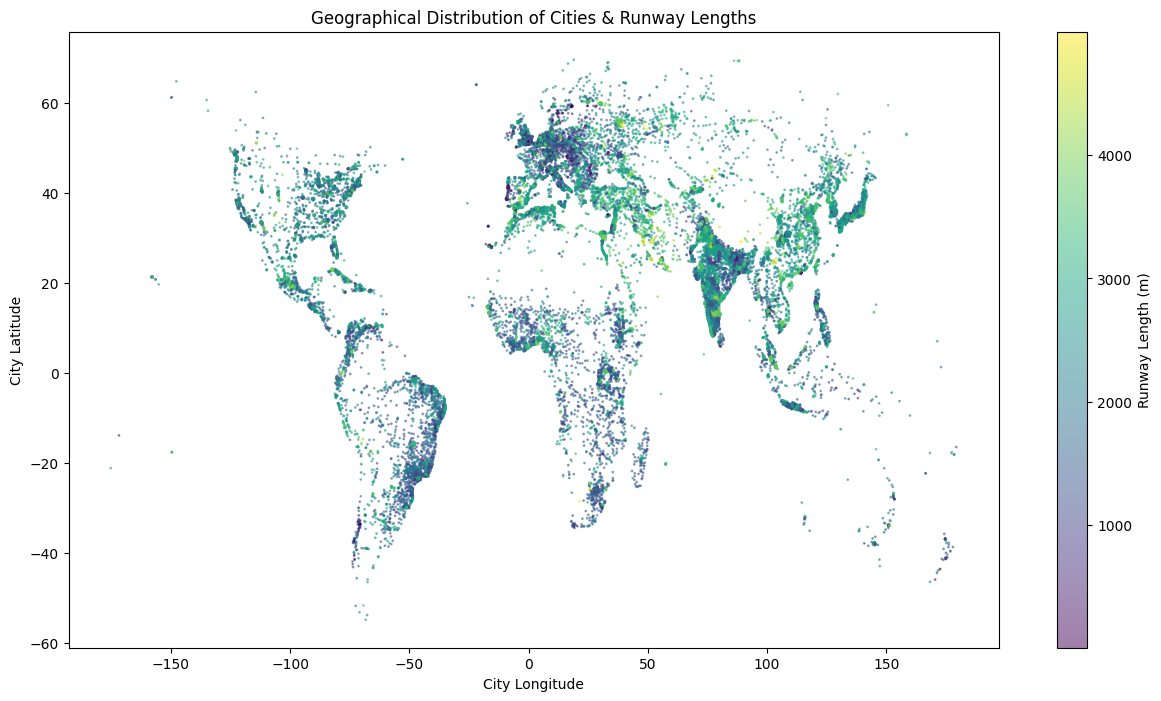

In [ ]:
#Geographical POV -'pseudo world map' of cities

#Scatterplot of city latitude/longitude and runway lengths
plt.figure(figsize=(15, 8))
plt.scatter(master_df['city_lon'],
            master_df['city_lat'],
            c=master_df['nearest_runway_length_m'],
            cmap='viridis',
            s=1, #s is short for size of the dots. 1 keeps the dots small so that they do not overlap each other with 26000+ dots
            alpha=0.5)
plt.colorbar(label='Runway Length (m)')
plt.title('Geographical Distribution of Cities & Runway Lengths')
plt.xlabel('City Longitude')
plt.ylabel('City Latitude')
plt.show()

A scatterplot of city latitude and longitude reveals the geographical map of where the cities are located, along with the fact that most runway lengths are around 3000m long (greens) and blues (around 2000m)

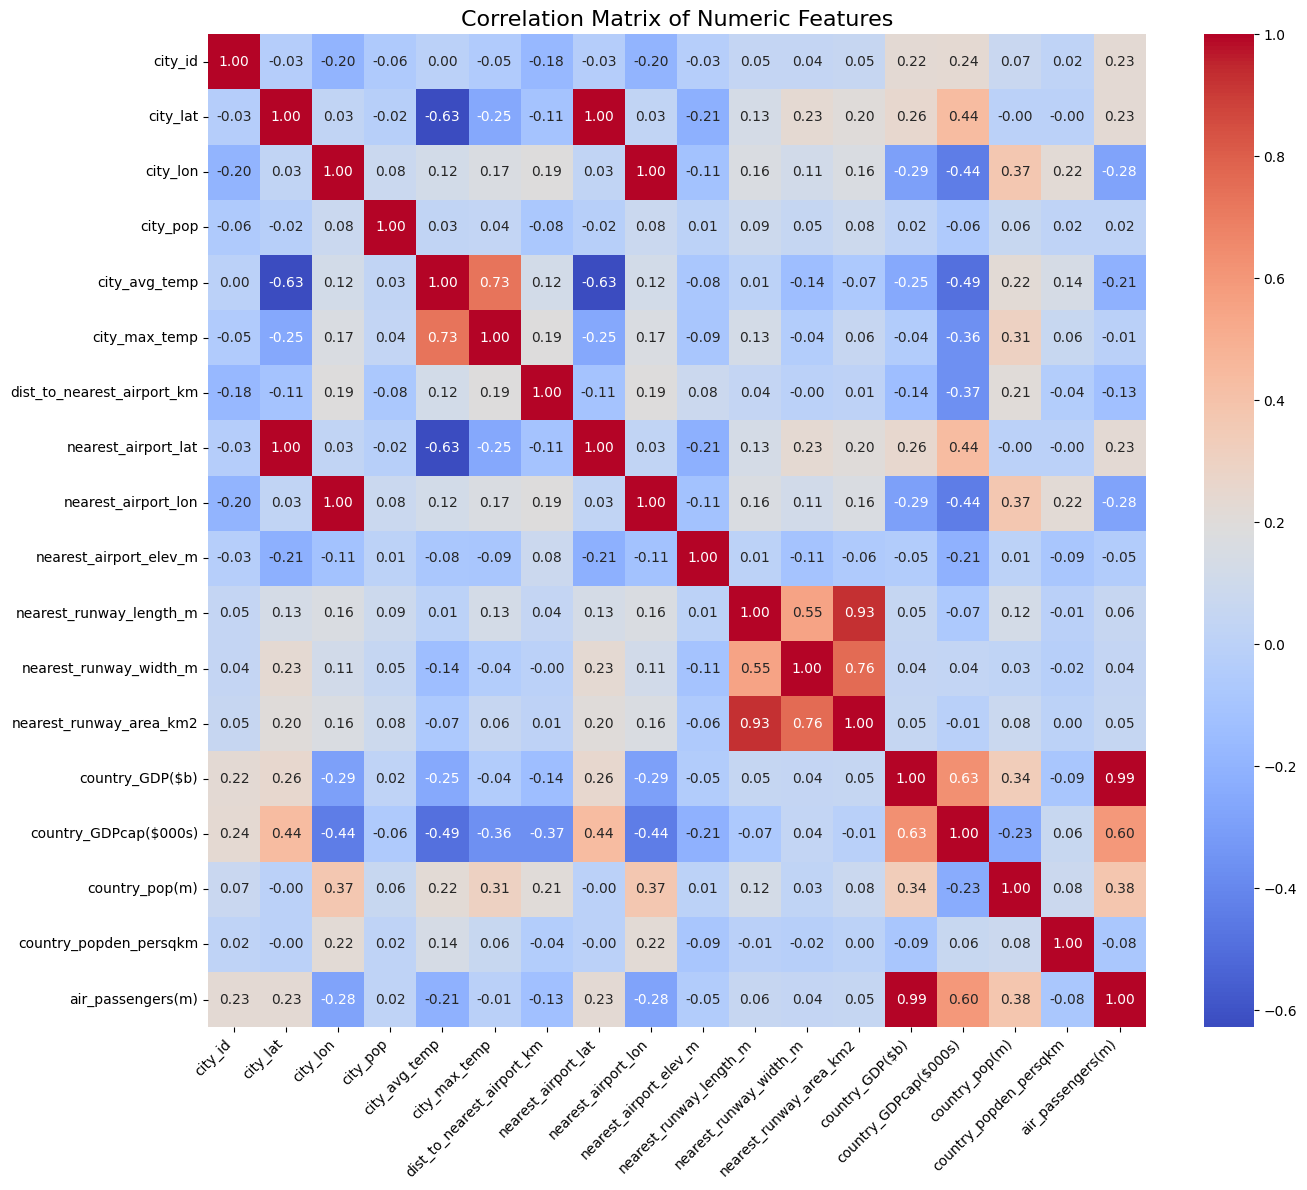

In [ ]:
#B. Correlation Matrix & Feature Impact
#using all the numeric columns to create the correlation matrix

numerical_cols = master_df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = master_df[numerical_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True, #see the numbers
    fmt=".2f", #format of how many decimal places
    cmap='coolwarm'
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Sort the measures that have the most impact, for runway length
#regardless of positive or negative correlation value

corr_with_target = corr_matrix['nearest_runway_length_m'].abs().sort_values(ascending=False)
corr_with_target

nearest_runway_length_m       1.000000
nearest_runway_area_km2       0.925320
nearest_runway_width_m        0.553723
city_lon                      0.162484
nearest_airport_lon           0.162445
city_lat                      0.131204
nearest_airport_lat           0.131090
city_max_temp                 0.128448
country_pop(m)                0.124426
city_pop                      0.086192
country_GDPcap($000s)         0.069481
air_passengers(m)             0.056451
country_GDP($b)               0.048229
city_id                       0.046023
dist_to_nearest_airport_km    0.040194
country_popden_persqkm        0.007720
nearest_airport_elev_m        0.006803
city_avg_temp                 0.005304
Name: nearest_runway_length_m, dtype: float64

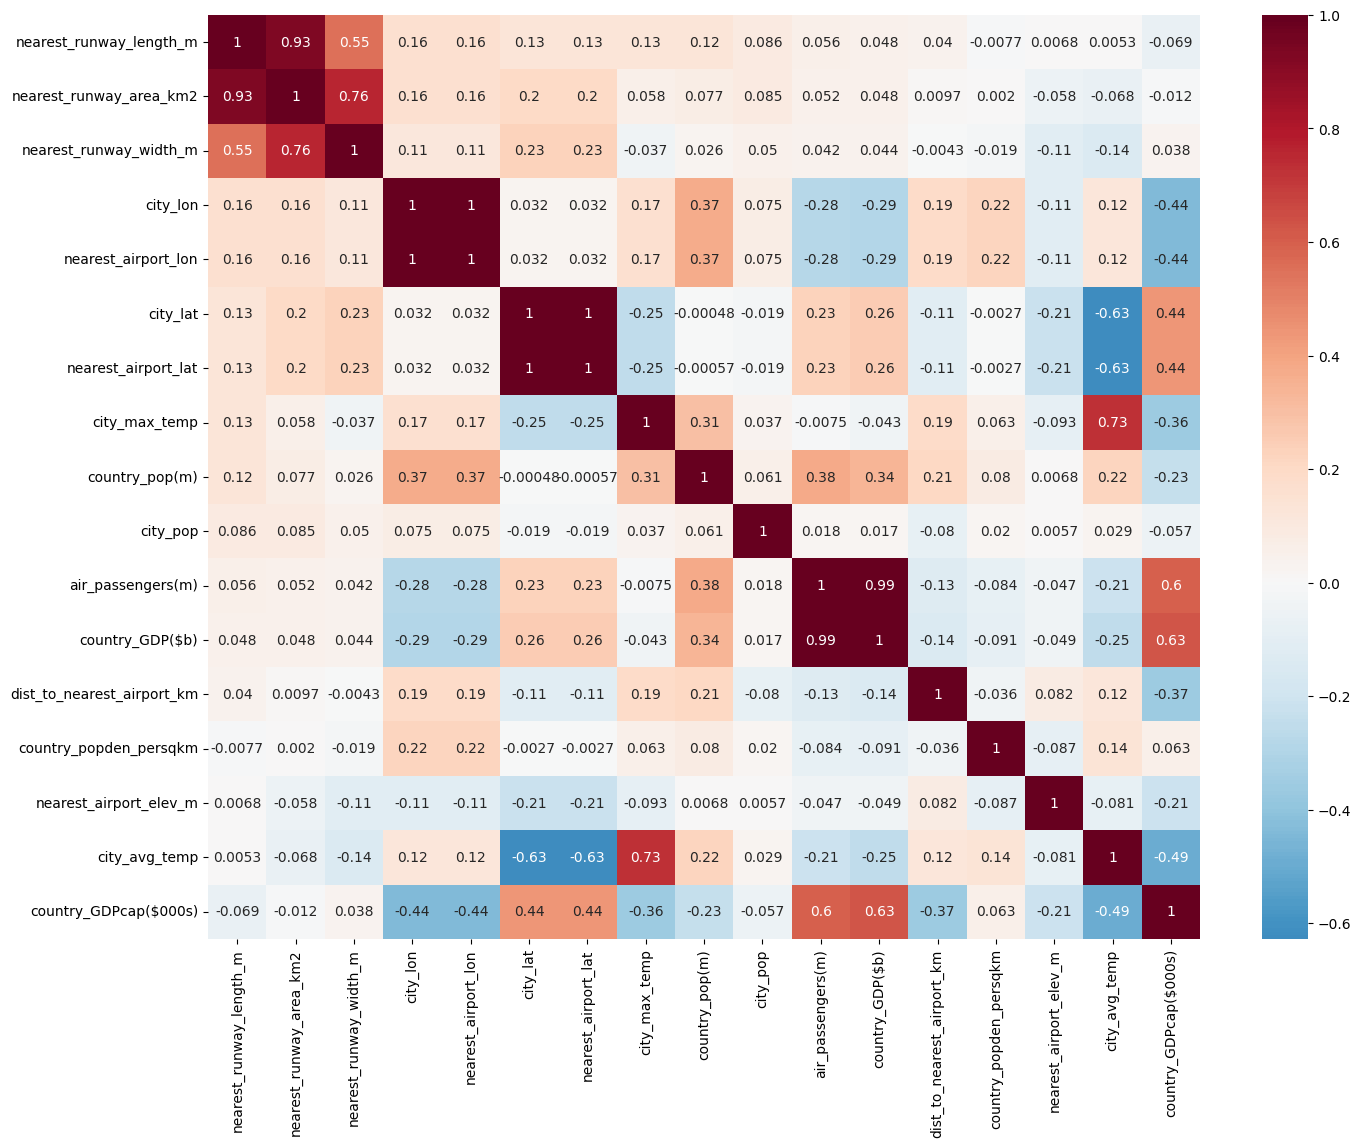

In [ ]:
#To focus on the features with higher correlation values for airport runway length

master_df_filtered = master_df[['nearest_runway_length_m', 'nearest_runway_area_km2',
                                    'nearest_runway_width_m', 'city_lon', 'nearest_airport_lon',
                                    'city_lat', 'nearest_airport_lat', 'city_max_temp',
                                    'country_pop(m)', 'city_pop', 'air_passengers(m)', 'country_GDP($b)',
                                    'dist_to_nearest_airport_km', 'country_popden_persqkm',
                                    'nearest_airport_elev_m', 'city_avg_temp', 'country_GDPcap($000s)']]

#Correlation Matrix of filtered measures
plt.figure(figsize=(16, 12))
corr_matrix2 = master_df_filtered.corr()
sns.heatmap(corr_matrix2,
            annot=True,
            cmap='RdBu_r',
            center=0)
plt.show()

We can quickly see that geographical factors like the latitude and longitude of a city, and its climate and weather, have the strongest correlation to runway lengths. The next group of factors are population-related measures (population sizes and densities, as well as air passenger volumes). The third group of factors are GDP measures

In [ ]:
#C. Categorical Analysis

C:\Users\chery\AppData\Local\Temp\ipykernel_20216\1230222248.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='city_tier', y='nearest_runway_length_m', data=master_df, order=tier_order, palette='Set2')


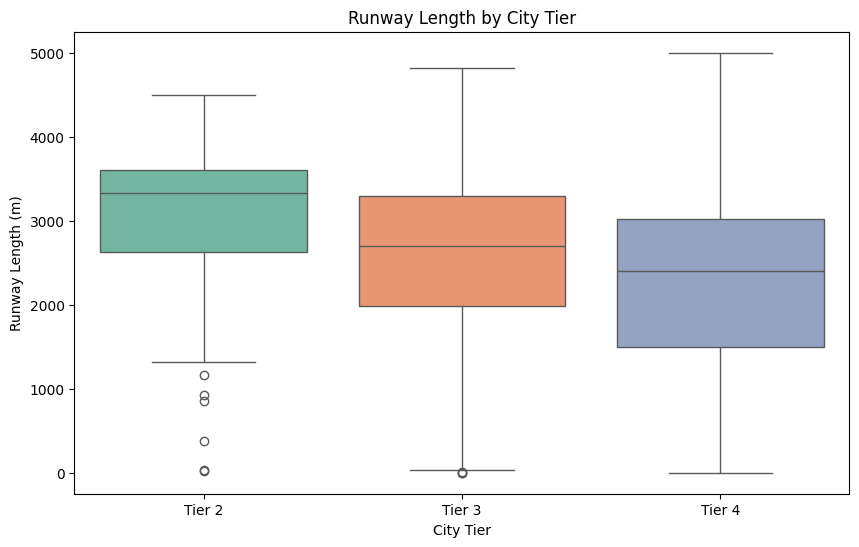

In [ ]:
#Boxplot of Runway Length by City Tier

plt.figure(figsize=(10, 6))


tier_order = sorted(master_df['city_tier'].unique()) #sorted organises the df into a 'logical' order for eg alphabetical or numerical order
sns.boxplot(x='city_tier', y='nearest_runway_length_m', data=master_df, order=tier_order, palette='Set2')

plt.title('Runway Length by City Tier')
plt.xlabel('City Tier')
plt.ylabel('Runway Length (m)')
plt.show()

In [ ]:
tier_stats = master_df.groupby('city_tier')['nearest_runway_length_m'].agg([
    'count',
    'mean',
    'min',
    lambda x: x.quantile(0.25),
    'median',
    lambda x: x.quantile(0.75),
    'max'
]).rename(columns={
    '<lambda_0>': '25th_percentile',
    'median': '50th_percentile',
    '<lambda_1>': '75th_percentile'
})

print("--- Runway Length Statistics by City Tier (in meters) ---")
print(tier_stats)

--- Runway Length Statistics by City Tier (in meters) ---
           count         mean      min  25th_percentile  50th_percentile  \
city_tier                                                                  
Tier 2       110  3011.600632  24.0792        2628.8238        3330.7020   
Tier 3      3674  2603.295600   6.4008        1987.9056        2699.9184   
Tier 4     22204  2334.849683   6.0960        1499.9208        2399.9952   

           75th_percentile        max  
city_tier                              
Tier 2           3600.2976  4500.0672  
Tier 3           3300.0696  4817.9736  
Tier 4           3023.6160  4999.9392  


We see another interesting pattern here.
First, there is a clear 'step-down' in average runway length as we move down from Tier 2 to Tier 4. The more populated a city is, the longer the runway length of the nearest airport. Tier 2 cities averages around 700m more than Tier 4 nearest airport runway lengths. Furthermore, the 25th percentile of Tier 2 airports (approx. 2600m) is still larger than the runway length mean of Tier 4 nearest airports (approx. 2300m).

This is expected, as cities with more population density support the presence of large airports with longer runway lengths. These airports are usually the main 'hub airports' of the city and/or country. They support larger passenger airline aircraft and cargo frieghters that support higher flows of people, social and economic activities.

Second, more populated cities (Tier 2 cities) have more similar sizes of runway lengths, and as cities become less populated (like Tier 4 cities), runway lengths become shorter on average but also more varied. This is evidenced by the height of the boxes getting longer as we move down the city tiering.

This is also expected, as large airports (which are usually located in more populated cities) are governed by standardised runway length guidelines by ICAO, that follow required minimum lengths for the largest aircraft model that uses the airport (reference URL - https://skybrary.aero/articles/icao-aerodrome-reference-code#:~:text=Table_title:%20Description%20Table_content:%20header:%20%7C%20Code%20number,aeroplane:%20Typical%20aeroplane%20BOEING%20737%2D700/AIRBUS%20A%2D320%20%7C)

The maximum nearby runway length of Tier 4 cities is actually higher than Tier 2 and 3 cities. This suggests also that some tier 4 cities are located very close to major airports with long runways.

It must be highlighted that 18% of runway lengths were imputed earlier during the data cleaning stage (~1700 / ~ 9500) with the means of each airport type (small, medium, large, helipads)

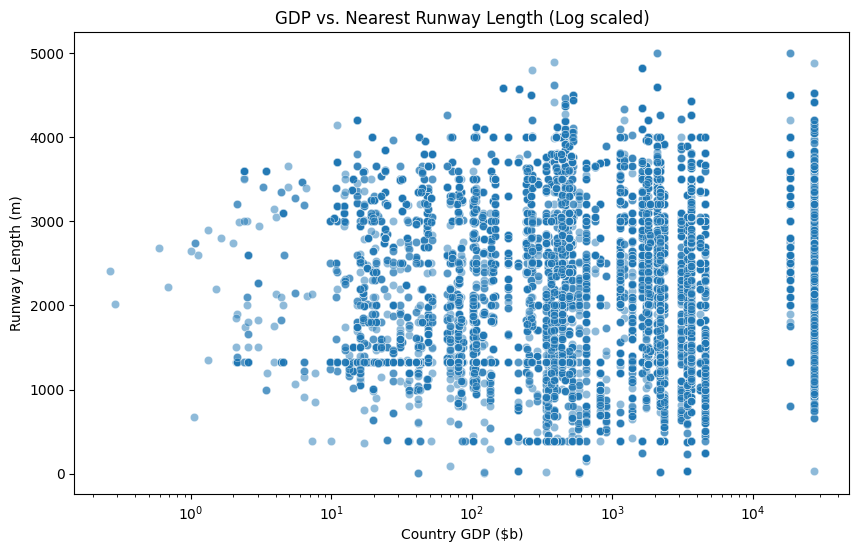

In [ ]:
#Scatterplot of GDP per capital vs Runway Length

plt.figure(figsize=(10, 6))
sns.scatterplot(x='country_GDP($b)', y='nearest_runway_length_m', data=master_df, alpha=0.5)
plt.title('GDP vs. Nearest Runway Length (Log scaled)')
plt.xlabel('Country GDP ($b)')
plt.ylabel('Runway Length (m)')
plt.xscale('log') #Use log scale as data is skewed
plt.show()

This scatterplot shows that there is some positive relationship between country-level GDP and runway length. Generally the higher the GDP, the larger the runway area. This is also consistent with the earlier explanation that airport sizes following GDP and economic activities, supporting flows of people and cargo.

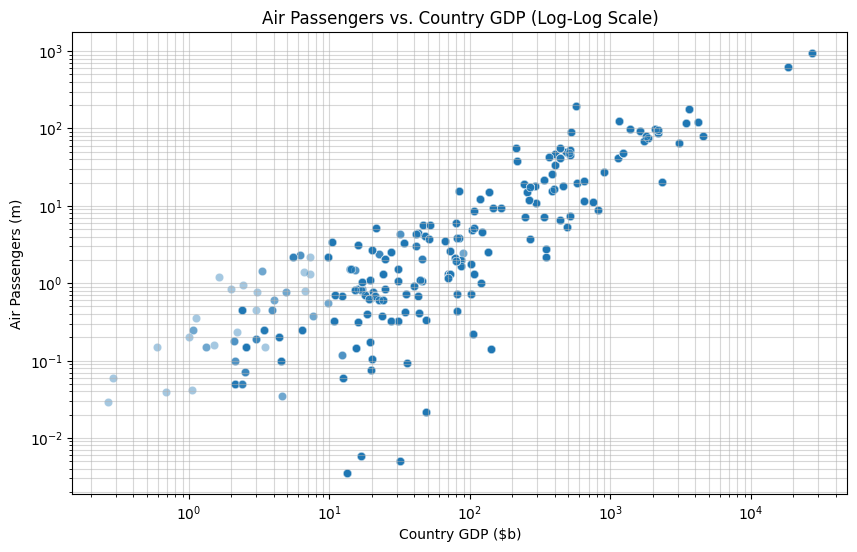

In [ ]:
#Air Passenger Volumes

#Scatterplot of Air Traffic versus GDP

plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='country_GDP($b)', y='air_passengers(m)', alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title('Air Passengers vs. Country GDP (Log-Log Scale)')
plt.xlabel('Country GDP ($b)')
plt.ylabel('Air Passengers (m)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Air passenger volume and country GDP have an almost perfectly positively correlated relationship to each other. It clearly shows that the power to spend is directly related to the desire and ability for people to fly and travel. Delving more into this insight, we can create a new measure 'passengers_per_capita (population)' versus GDP_per_capita', which refers to the number of people who fly versus the entire country population

In [ ]:
#Creating a new measure 'passengers_per_capita'

master_df['passengers_per_capita'] = (master_df['air_passengers(m)']) / (master_df['country_pop(m)'])

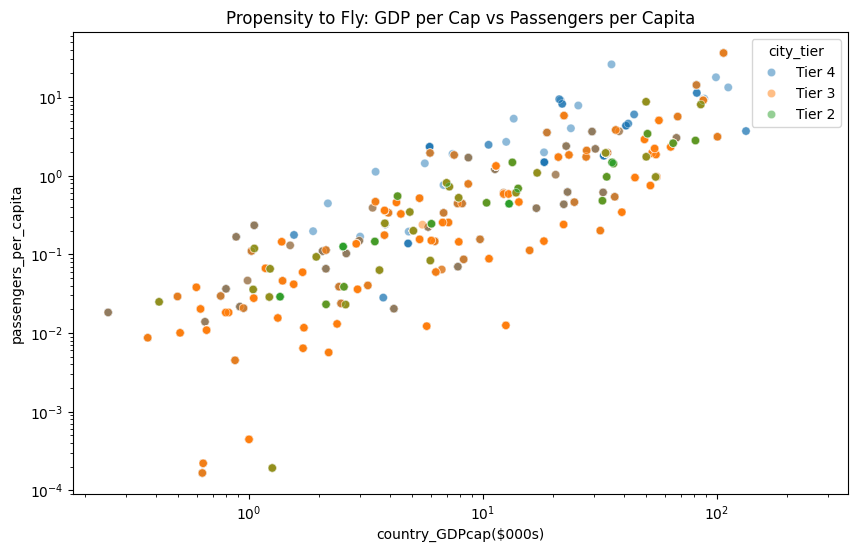

In [ ]:
#Scatterplot of Passengers per capital VS GDP per capita, differentiated by City Tier

plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='country_GDPcap($000s)', y='passengers_per_capita', alpha=0.5, hue='city_tier')
plt.xscale('log')
plt.yscale('log')
plt.title('Propensity to Fly: GDP per Cap vs Passengers per Capita')
plt.show()

This scatterplot reveals more insights about who is actually making up more of the air passenger population. Where one would assume that Tier 2 cities (green dots) would be occupying the upper part of the trend line, it is actually Tier 4 cities (blue dots) that are showing up. This means that on a per capita basis, there are more people moving around via air transport in Tier 3 cities that travel than Tier 2 cities.

Text(0.5, 1.0, 'Air Passengers vs. Nearest Runway Length')

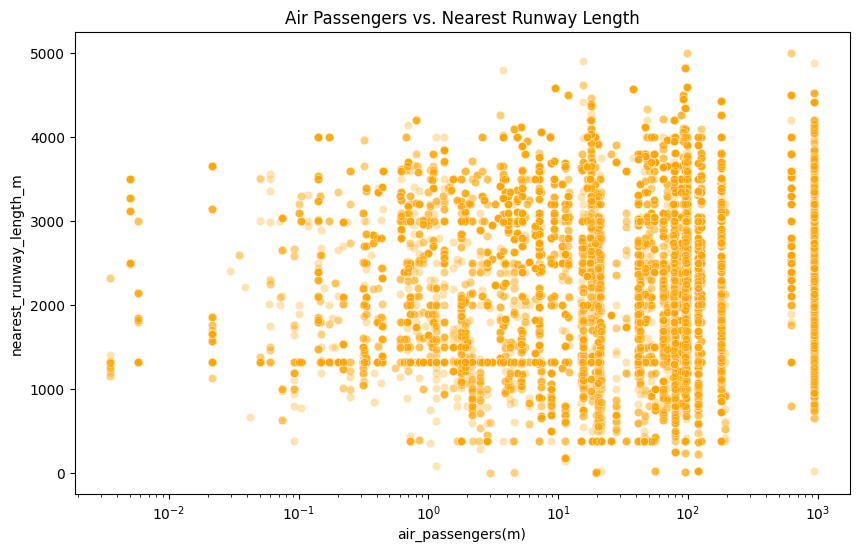

In [ ]:
#Scatterplot of Air passengers VS Runway Length

plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='air_passengers(m)', y='nearest_runway_length_m', alpha=0.3, color='orange')
plt.xscale('log')
plt.title('Air Passengers vs. Nearest Runway Length')

Interestingly, there is not much of a correlation between air passengers (at a country level) and runway length. What this reveals is that runway length of airports at a city level are not clearly related to air passengers at a country level. Also, airport authorities tend to make forecasts based on air traffic volumes, though the data suggests that there is no strong relationship (0.056 correlation value).

In [ ]:
#Elevation & Temperature - Physical & Geographic Constraints

In terms of the physics of flight, at higher elevations, air becomes thinner and provides less lift (thrust for aircraft engines) and drag (friction) on an aircraft's wings. Hence, runways need to be longer in order to allow for more take off and landing distances, to allow an aircraft to have enough lift to take off, or to bring the aircraft safely to a stop.

Text(0.5, 1.0, 'Airport Elevation vs. Runway Length')

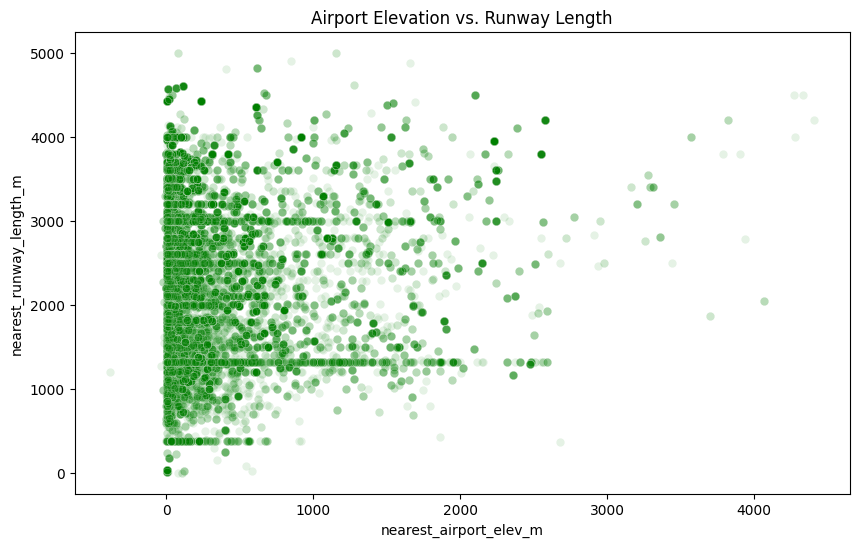

In [ ]:
#Scatterplot of Cities VS Runway Length

plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df,
                x='nearest_airport_elev_m',
                y='nearest_runway_length_m',
                alpha=0.1,
                color='green')
plt.title('Airport Elevation vs. Runway Length')

From this scatterplot of all (nearest) airport elevations versus runway lengths, we can see that not all long runways are found necessarily only in airports with high elevation, but airports with high elevation (eg above 3000m), have longer runways of at least around 2000m.

Taking a closer look at this relationship by looking at city tiers with the highest airport elevations, and how this ties to runway lengths, the target variable

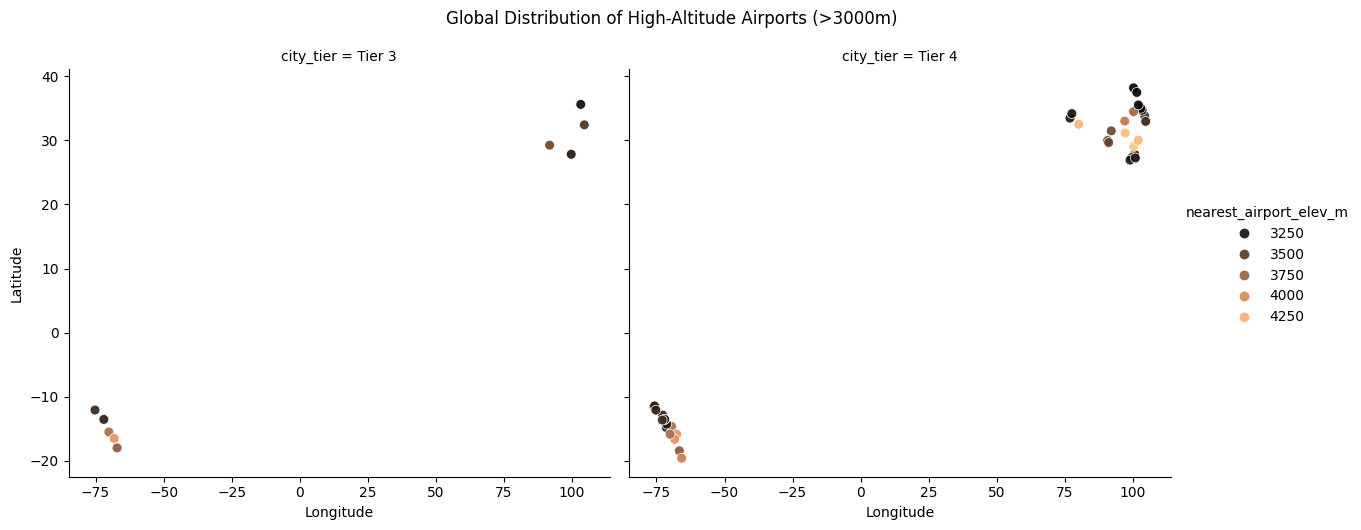

In [ ]:
#Replot of City Tiers with Airport Elevation of >3000m

#Creates a temporary dataframe looking only at airports located at very high elevation of >3000m
high_elev_df = master_df[master_df['nearest_airport_elev_m'] > 3000].copy()

#Plotting
g = sns.relplot(
    data=high_elev_df,
    x="city_lon",
    y="city_lat",
    hue="nearest_airport_elev_m",
    col="city_tier",
    col_wrap=2,
    palette="copper",
    s=50, #size of dots
    alpha=0.9,
    height=5,
    aspect=1.2,
    col_order=['Tier 3', 'Tier 4'] #Since only cities in Tier 3 and 4 meet this criteria
)

g.set_axis_labels("Longitude", "Latitude")
g.fig.suptitle("Global Distribution of High-Altitude Airports (>3000m)", y=1.05)
plt.show()

This graph shows firstly that airports at high elevations are all clustered together geographically in mountaineous areas of the Earth's surface, around similar latitudes and longitudes. For eg, around latitude -10 to -20 longitude -60 to -75, which are locations in South America, particularly countries like Brazil, Bolivia and Peru. And around latitude 28 to 40 longitude 80-100, which are the regions of Central and East Asia, particularly West of China, Nepal and India. We can look at some examples of these cities

C:\Users\chery\AppData\Local\Temp\ipykernel_20216\1852081349.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities_infra.values, y=top_cities_infra.index, palette='viridis')


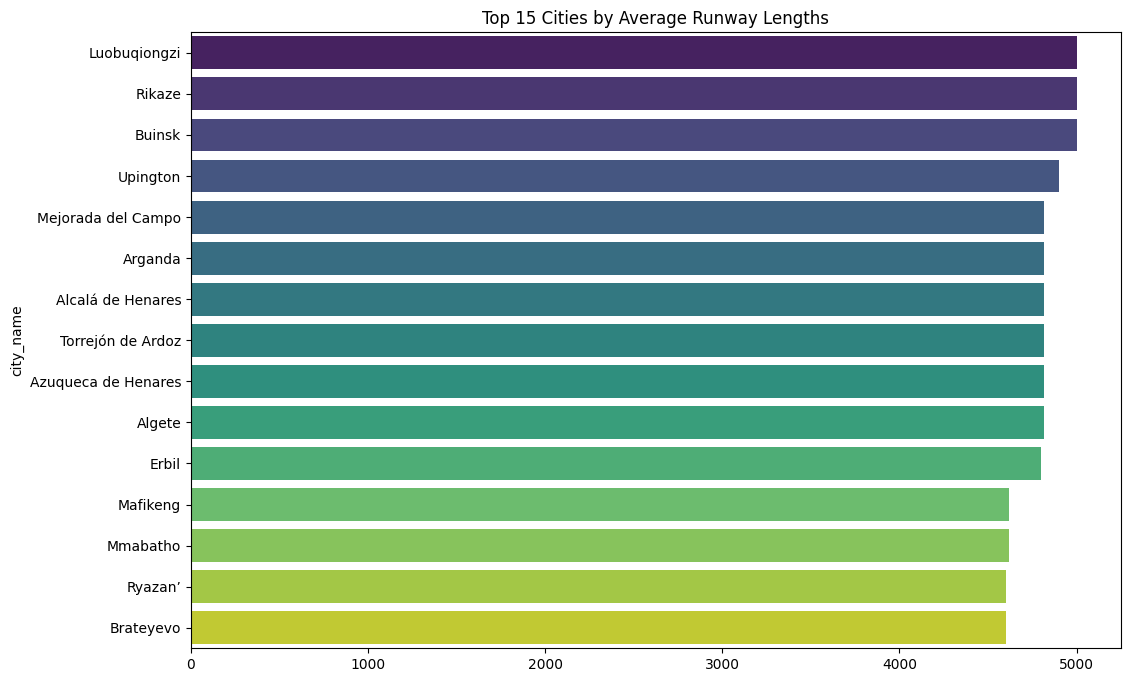

In [ ]:
#Average Runway Lengths by Top 15 Cities

plt.figure(figsize=(12, 8))
top_cities_rl = master_df.groupby('city_name')['nearest_runway_length_m'].mean().sort_values(ascending=False).head(15)
sns.barplot(x=top_cities_rl.values, y=top_cities_rl.index, palette='viridis')
plt.title('Top 15 Cities by Average Runway Lengths')
plt.show()

This graph reveals lesser known city names with the longest (nearby airport) runway lengths, that are likely Tier 3, if not Tier 4 cities

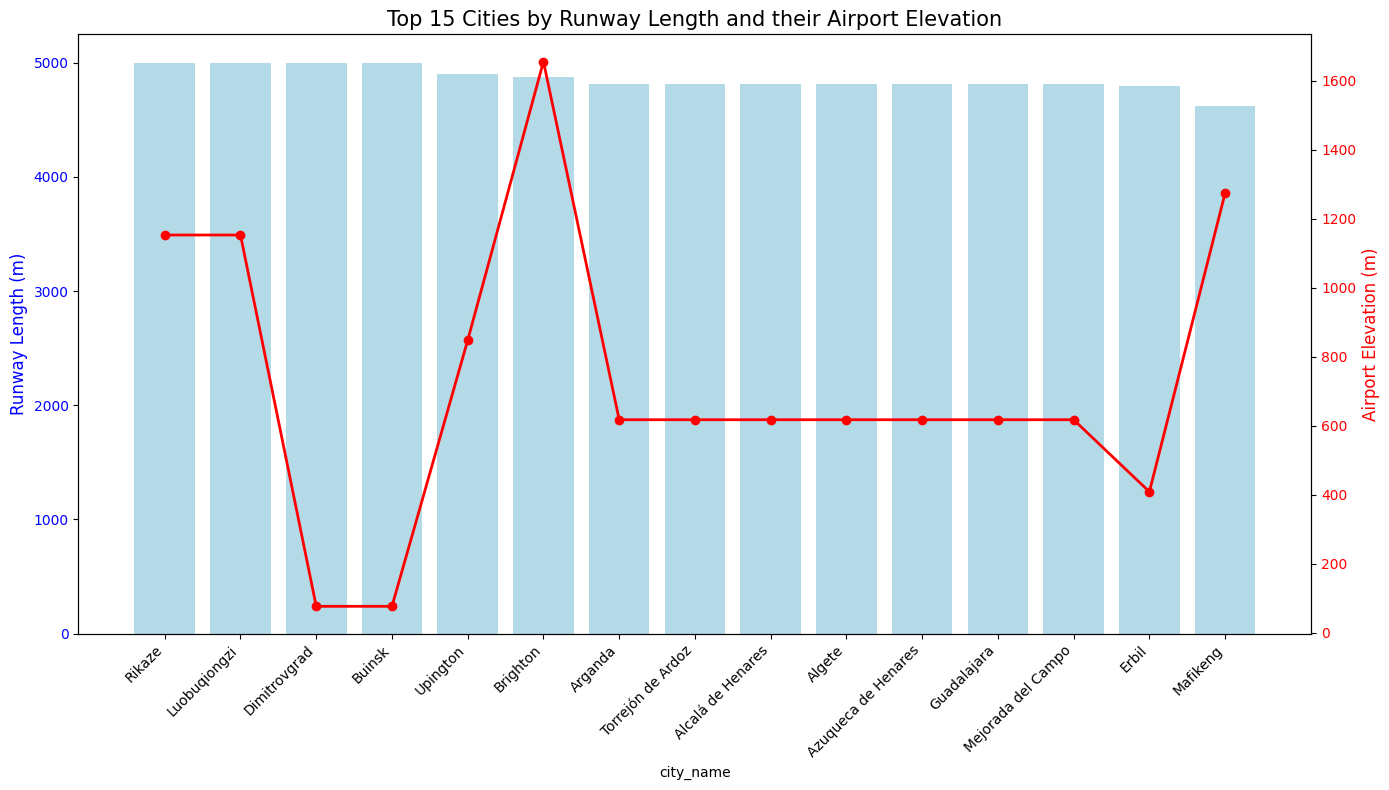

In [ ]:
#Dual y-axis graph of Runway Length by Airport Elevation

top_15_runway = master_df.sort_values(by='nearest_runway_length_m', ascending=False).head(15)

fig, ax1 = plt.subplots(figsize=(14, 8))

##Bar chart for first axis - Runway Length
sns.barplot(x='city_name', y='nearest_runway_length_m', data=top_15_runway, ax=ax1, color='skyblue', alpha=0.7)
ax1.set_ylabel('Runway Length (m)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Top 15 Cities by Runway Length and their Airport Elevation', fontsize=15)
plt.xticks(rotation=45, ha='right')

##Second axis for Elevation
ax2 = ax1.twinx()
ax2.plot(top_15_runway['city_name'],
         top_15_runway['nearest_airport_elev_m'],
         color='red',
         marker='o',
         linestyle='-',
         linewidth=2,
         label='Elevation')
ax2.set_ylabel('Airport Elevation (m)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

fig.tight_layout()

Indeed, this dual-axis graph confirms the above suspicion. Out of the top 15 runway lengths (by the city's nearest airport), only 2 are below 400m, and 3 are below 600m.  

This also explains the observation from an earlier boxplot of the city tiers and runway lengths. Tier 4 cities located in such higher elevations that have (nearest) airports with long runways show that GDP and socio-economic activity is only part of the picture contributing to the need to have long runways. Often such cities are limited in their population precisely due to their high-altitudes that may make living abit more inconvenient. Hence, while GDP fuels longer runways, geographical constraints (high altitude) necessitates longer runways. That is why Tier 4 cities have a wider range of runway length distributions from shorter to longer runways

C:\Users\chery\AppData\Local\Temp\ipykernel_20216\3747727325.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries_infra.values, y=top_countries_infra.index, palette='viridis')


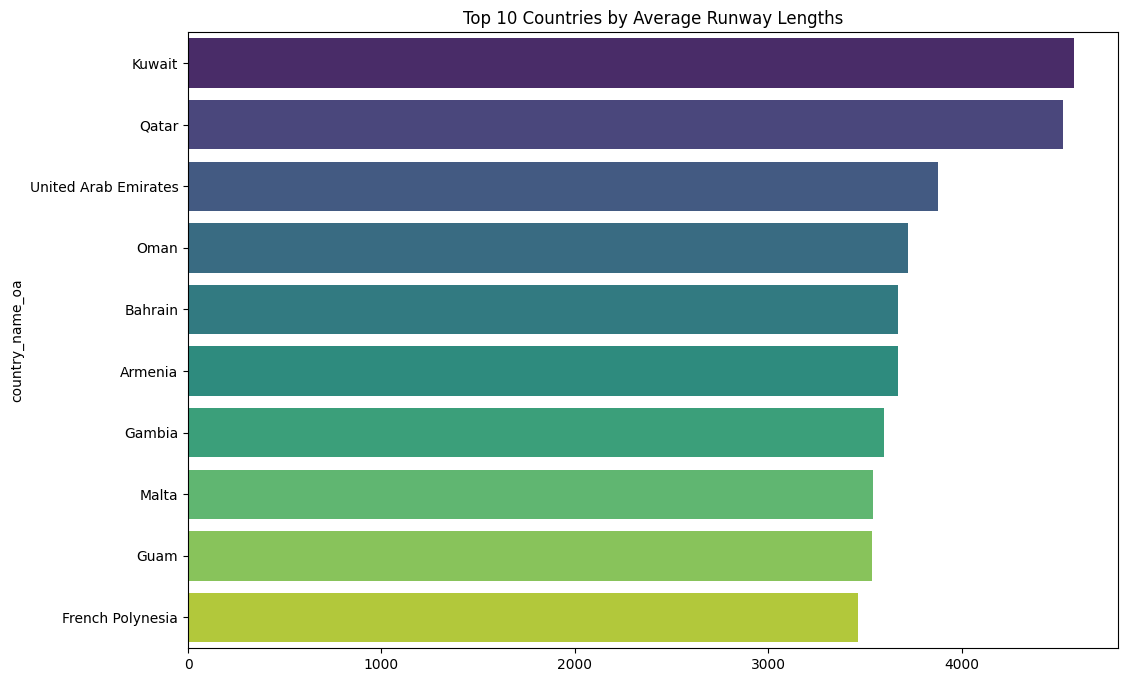

In [ ]:
#Average Runway Lengths by Top 10 Countries

plt.figure(figsize=(12, 8))
top_countries_rl = master_df.groupby('country_name_oa')['nearest_runway_length_m'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries_rl.values, y=top_countries_rl.index, palette='viridis')
plt.title('Top 10 Countries by Average Runway Lengths')
plt.show()

This shows the dominance of Middle Eastern countries (Kuwait, Qatar, UAE, Oman, Bahrain) in terms of having the longest runways. Middle Eastern countries have geographical superiority, being 'in the middle of the world' and hence are major hubs for airlines to transit their passengers for long-haul flight journeys. They also have strong GDP to support the building of and need for large airport infrastructure

Another key physical constraint is the temperature (or, weather and climate) of the city and its nearest airport location. Generally, the warmer the temperature, the thinner the air, more braking distance is needed, and therefore longer runways are needed. In particular, the maximum city temperatures are more important than the average city temperatures.

In [ ]:
#City Temperatures

temp_corr_matrix = master_df[['city_avg_temp', 'city_max_temp', 'nearest_runway_length_m', 'nearest_airport_elev_m']].corr()
print("\n--- Correlation Matrix of City Temperatures ---")
temp_corr_matrix


--- Correlation Matrix of City Temperatures ---


,city_avg_temp,city_max_temp,nearest_runway_length_m,nearest_airport_elev_m
city_avg_temp,1.000000,0.727274,0.005304,-0.081177
city_max_temp,0.727274,1.000000,0.128448,-0.093023
nearest_runway_length_m,0.005304,0.128448,1.000000,0.006803
nearest_airport_elev_m,-0.081177,-0.093023,0.006803,1.000000


In this correlation matrix, we see that a city's maximum temperature has a correlation value of 0.13 versus -0.0053 for city average temperature. This means that the maximum city temperatures are more important than the average city temperatures. This confirms the fact that airport runways are designed to handle the hottest days, not the just the average ones, because the airport (the runway) needs to still be safe even on the warmest days

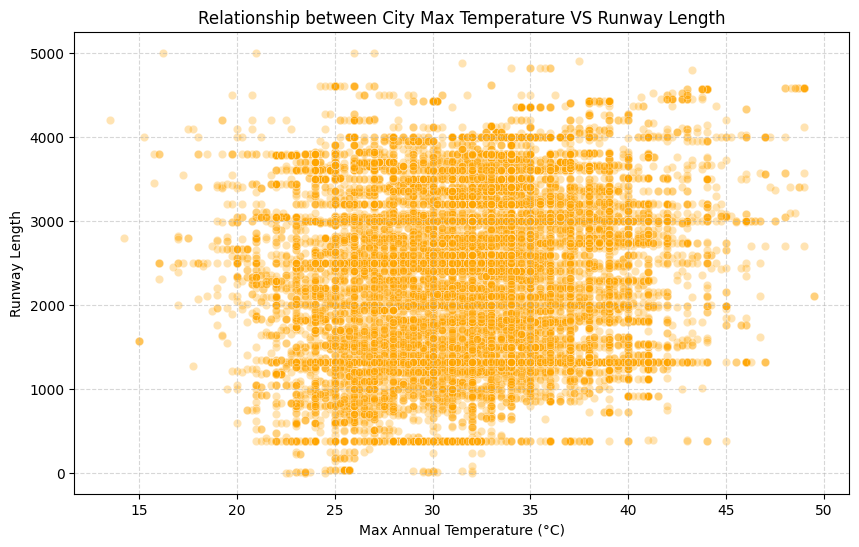

In [ ]:
#Scatterplot of Maximum City Temp VS Runway Length

plt.figure(figsize=(10, 6))
sns.scatterplot(x='city_max_temp', y='nearest_runway_length_m', data=master_df, alpha=0.3, color='orange')
plt.title('Relationship between City Max Temperature VS Runway Length')
plt.xlabel('Max Annual Temperature (°C)')
plt.ylabel('Runway Length')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Modelling

There are features in the dataset that are highly or related to each other - for example, country GDP and GDP per capita, country population and city population, runway-related measures.

Using Ridge Regression model is better than Linear Regression, as it handles such multi-collinearity better, and prevents being over-reactive to these overlapping features.

What may be better than Ridge Regression is Random Forest Regressor. This is because airport infrastructure does not grow 'linearly', for eg 1km2 every 2 years. It usually expands 'non-linearly' - for eg 3km sq for 30 years, before another 2km sq gets added for the next 25 years. Another strong reason to use Random Forest is that it provides feature importance, which allows me to compare exactly how much one feature is more important than another.

This is the sequence of models that will be used
1. Null Accuracy (Baseline) Model

2. Ridge Regression (Finding linear relationship)

3. Random Forest Regressor (Finding non-linear relationship)

In [ ]:
#Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


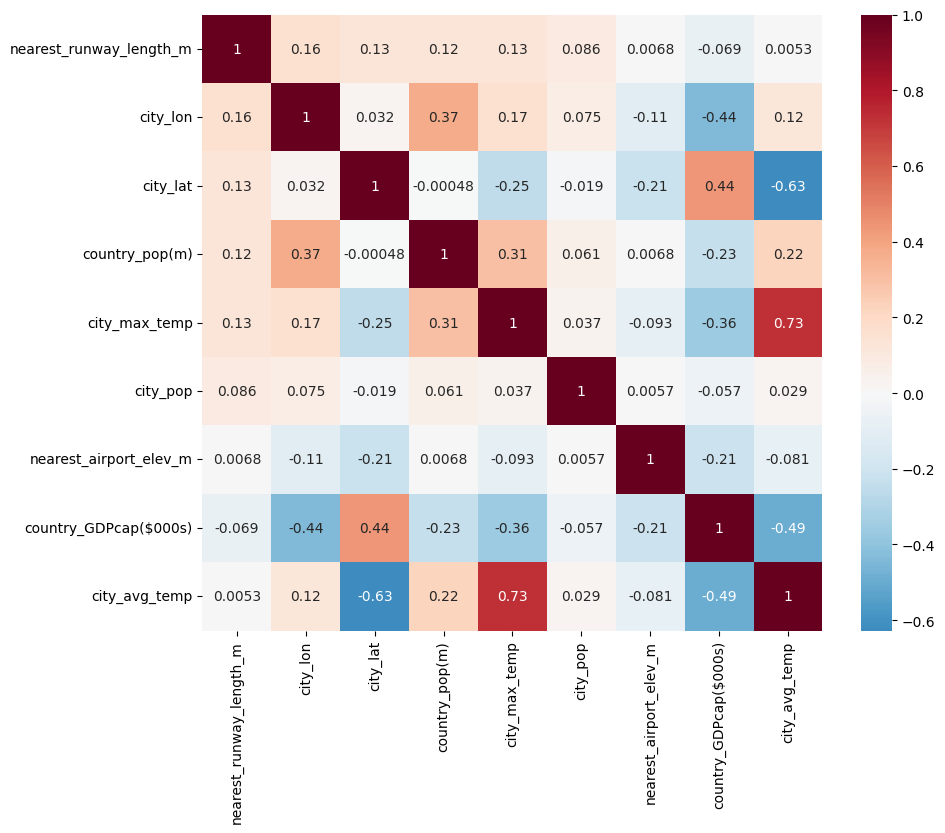

In [ ]:
#To reiterate, these are the features that have shown higher correlation to the y target variable - runway land area
master_df_filtered = master_df[['nearest_runway_length_m', 'nearest_runway_area_km2',
                                    'nearest_runway_width_m', 'city_lat',
                                  'city_avg_temp', 'city_lon', 'city_pop',
                                  'country_pop(m)', 'nearest_airport_elev_m', 'air_passengers(m)',
                                    'country_GDP($b)', 'city_max_temp', 'country_GDPcap($000s)',
                                'dist_to_nearest_airport_km']]

#However, due to the nature of some features that are related to each other,
#to further cut down on the features to reduce multi-collinearity

##Runway-related features are all removed
##Air passenger has shown itself to be only weakly related to runway length in EDA
##Total country GDP was removed in favour of GDP per capita as that is a more fair and objective economic measure
narrowed_df = master_df[['nearest_runway_length_m', 'city_lon', 'city_lat', 'country_pop(m)',
                         'city_max_temp', 'city_pop', 'nearest_airport_elev_m',
                        'country_GDPcap($000s)', 'city_avg_temp']]
#Though there are 8 features (minus y target variable), essentially, there are 6 main features,
#since city latitude and longitude go together,
#and city average and maximum temperatures also go together

plt.figure(figsize=(10, 8))
corr_matrix2 = narrowed_df.corr()
sns.heatmap(corr_matrix2, annot=True, cmap='RdBu_r', center=0)
plt.show()

In [ ]:
#Preparing features

features = ['city_lon', 'city_lat', 'country_pop(m)',
                         'city_max_temp', 'city_pop', 'nearest_airport_elev_m',
                        'country_GDPcap($000s)', 'city_avg_temp']
target = 'nearest_runway_length_m'

#Dropping rows with missing values
df_clean = master_df.dropna(subset=features + [target])

#Setting up variable X,y
X = df_clean[features]
y = df_clean[target]

#Splittling data into 80/20 and scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Scaling data since there are of varying scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset ready. Training on {len(df_clean)} records.")

Dataset ready. Training on 25988 records.


In [ ]:
#Null Accuracy (Base Model)

y_null_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())

null_r2 = r2_score(y_test, y_null_pred)
null_rmse = np.sqrt(mean_squared_error(y_test, y_null_pred))

print("\n--- Model 1: Null Model (Baseline) ---")
print(f"Null R2: {null_r2:.4f}")
print(f"Null RMSE: {null_rmse:.2f}")


--- Model 1: Null Model (Baseline) ---
Null R2: -0.0001
Null RMSE: 937.97


In [ ]:
#Ridge Regression

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_ridge_pred = ridge.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, y_ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_ridge_pred))

print("\n--- Model 2: Ridge Regression ---")
print(f"Ridge R2: {ridge_r2:.4f}")
print(f"Ridge RMSE: {ridge_rmse:.2f}")


--- Model 2: Ridge Regression ---
Ridge R2: 0.0732
Ridge RMSE: 902.93


In [ ]:
#Random Forest

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_rf_pred = rf.predict(X_test_scaled)

test_rf_r2 = r2_score(y_test, y_rf_pred)
test_rf_rmse = np.sqrt(mean_squared_error(y_test, y_rf_pred))

print("\n--- Model 3: Random Forest ---")
print(f"RF R2: {test_rf_r2:.4f}")
print(f"RF RMSE: {test_rf_rmse:.2f}")


--- Model 3: Random Forest ---
RF R2: 0.8277
RF RMSE: 389.31


In [ ]:
#Comparison of all 3 models

comparison = pd.DataFrame({
    'Model': ['Null Model', 'Ridge Regression', 'Random Forest'],
    'R2 Score': [null_r2, ridge_r2, rf_r2],
    'RMSE': [null_rmse, ridge_rmse, rf_rmse]
})
print("\n--- Performance Summary ---")
print(comparison)


--- Performance Summary ---
              Model  R2 Score        RMSE
0        Null Model -0.000143  937.971345
1  Ridge Regression  0.073182  902.933828
2     Random Forest  0.827701  389.313545


Hyperparameter Tuning

Settings for:
Ridge Regression - alpha 1.0
Random Forest - n_estimators=100

To improve model performance, the alpha and n estimator values can be tested through many different combinations of values at once, to find the 'best value'.

There are 2 main methods to do this searching of best values.

One is called 'GridSearchCV'. This method searches through every value that is explicitly defined eg alpha = 0.1, 1, 10 etc. This is exhaustive but slower.

Another is called 'RandomizedSearchCV'. This method searches through a random selection of combinations. This is faster

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#Tuning Ridge Regression

ridge_params = {'alpha': [0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

best_ridge = ridge_grid.best_estimator_
y_ridge_pred = best_ridge.predict(X_test_scaled)

tuned_ridge_r2 = ridge_grid.best_score_
tuned_ridge_rmse = np.sqrt(mean_squared_error(y_test, y_ridge_pred))

print("--- Ridge Regression Results ---")
print(f"Best Alpha: {ridge_grid.best_params_}")
print(f"Best CV R2 Score: {ridge_grid.best_score_:.4f}")
print(f"Test Set R2 Score: {r2_score(y_test, y_ridge_pred):.4f}")
print(f"Test Set RMSE: {tuned_ridge_rmse:.2f} meters")

--- Ridge Regression Results ---
Best Alpha: {'alpha': 100}
Best CV R2 Score: 0.0733
Test Set R2 Score: 0.0732
Test Set RMSE: 902.93 meters


In [ ]:
#Tuning Random Forest

#As the dataset is large, only selecting 5000 random cities for tuning, to reduce processing time
X_train_tune = X_train_scaled[:5000]
y_train_tune = y_train.iloc[:5000]

rf_params = {
    'n_estimators': [100, 200], #number of 'trees in the forest' that will 'vote' on which is the best prediction
    'max_depth': [5, 10, 15],
    #This is the 'height of the decision tree'. The larger the value, the more memory
    #of the data it will take in account before having to stop and give a prediction
    #However, a larger value makes the tree too complicated and cause overfitting
    'min_samples_split': [2, 6, 10],
    #This is the minimum number of data points that must be in a node before the tree is allowed
    #to split it into 2 more branches. It prevents branches from being created that only apply to
    #1 or 2 cities. This helps the model to generalise better
    'max_features': ['sqrt', 'log2']
    #This is the number of features that the tree is allowed to consider when deciding
    #how to make a split in branches
    #'sqrt' - the square root of the total number
    #'log2' - the base-2 logarithm of the total number
    #'none' - looks at all features
}

#Using RandomizedSearchCV as Random Forest has too many combinations for a full grid search for 26000 rows
rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    random_state=42,

)

print("Searching for best parameters on 5k sample...")
rf_random.fit(X_train_tune, y_train_tune)

print(f"Best Params found: {rf_random.best_params_}")
print(f"Best CV R2 Score (from sample): {rf_random.best_score_:.4f}")

Searching for best parameters on 5k sample...
Best Params found: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 15}
Best CV R2 Score (from sample): 0.4672


In [ ]:
#Training on full dataset

print("\n--- Training final model on full dataset... ---")
# his creates a new model using the best settings found above
final_rf = rf_random.best_estimator_

#This trains it on all 26000 cities
final_rf.fit(X_train_scaled, y_train)

#Final Evaluation
y_tunedrf_pred = final_rf.predict(X_test_scaled)
test_tunedrf_rmse = np.sqrt(mean_squared_error(y_test, y_tunedrf_pred))
test_tunedrf_r2 = r2_score(y_test, y_tunedrf_pred)

print(f"Final Test Set R2 Score: {test_tunedrf_r2:.4f}")
print(f"Final Test Set RMSE: {test_tunedrf_rmse:.2f} meters")


--- Training final model on full dataset... ---
Final Test Set R2 Score: 0.7116
Final Test Set RMSE: 503.71 meters


In [ ]:
#Final Comparison

final_comparison = pd.DataFrame({
    'Model': ['Null Model', 'Ridge Regression', 'Tuned Ridge Regression', 'Random Forest', 'Tuned Random Forest'],
    'R2 Score': [null_r2, ridge_r2, tuned_ridge_r2, test_rf_r2, test_tunedrf_r2],
    'RMSE': [null_rmse, ridge_rmse, tuned_ridge_rmse, test_rf_rmse, test_tunedrf_rmse]
})
print("\n--- Final Performance Summary ---")
print(final_comparison)


--- Final Performance Summary ---
                    Model  R2 Score        RMSE
0              Null Model -0.000143  937.971345
1        Ridge Regression  0.073182  902.933828
2  Tuned Ridge Regression  0.073344  902.930426
3           Random Forest  0.827701  389.313545
4     Tuned Random Forest  0.711570  503.707671


This summary shows that Random Forest is indeed a more superior predictive model than Ridge Regression for case of this capstone, with around 70% improvement in R square values, and more than half in reduction of RMSE, from 900+m to 300+m.

Random Forest performed better than the tuned model both in terms of R2 (around 11%) and RMSE (around 120+m) scores

Next, we check the Training versus Testing accuracies of the RF and Tuned RF models, to check for overfitting

In [ ]:
#Checking the Testing Accuracy of Random Forest (pre-tuned, Model #3)

y_train_pred = rf.predict(X_train_scaled)  #Predictions on training data

#Calculate Training Metrics
train_rf_r2 = r2_score(y_train, y_train_pred)
train_rf_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("--- Random Forest Training VS Testing Performance ---")
print(f"TRAINING RF R2:   {train_rf_r2:.4f} | TRAINING RF RMSE: {train_rf_rmse:.2f}")
print(f"TESTING RF R2:    {test_rf_r2:.4f} | TESTING RF RMSE:  {test_rf_rmse:.2f}")

#Calculate the difference
print(f"\nRF R2 Gap (Overfitting): {train_r2 - test_r2:.4f}")

--- Random Forest Training VS Testing Performance ---
TRAINING RF R2:   0.9744 | TRAINING RF RMSE: 149.81
TESTING RF R2:    0.8277 | TESTING RF RMSE:  389.31

RF R2 Gap (Overfitting): 0.1467


In [ ]:
#Checking the Testing Accuracy of Tuned RF

tunedrf_y_train_pred = final_rf.predict(X_train_scaled) #Predictions on training data

#Getting the R2 score of the Training set
train_tunedrf_r2 = final_rf.score(X_train_scaled, y_train)
train_tunedrf_rmse = np.sqrt(mean_squared_error(y_train, tunedrf_y_train_pred))

print("--- Tuned Random Forest Performance ---")
print(f"TRAINING Tuned RF R2:   {train_tunedrf_r2:.4f} | TRAINING Tuned RF RMSE: {train_tunedrf_rmse:.2f}")
print(f"TESTING Tuned RF R2:    {test_tunedrf_r2:.4f} | TESTING Tuned RF RMSE:  {test_tunedrf_rmse:.2f}")

#Calculate the difference
print(f"\nR2 Tuned RF Gap (Overfitting): {train_tunedrf_r2 - test_tunedrf_r2:.4f}")


--- Tuned Random Forest Performance ---
TRAINING Tuned RF R2:   0.8524 | TRAINING Tuned RF RMSE: 359.57
TESTING Tuned RF R2:    0.7116 | TESTING Tuned RF RMSE:  503.71

R2 Tuned RF Gap (Overfitting): 0.1408


The overfitting check shows that the both the (pre-tuned) and tuned RF have 14% of difference between training and testing accuracy.

In that case, the (pre-tuned) Random Forest model is actually better due to the lower RMSE score and higher R2 score. Hence, the Random Forest model is chosen

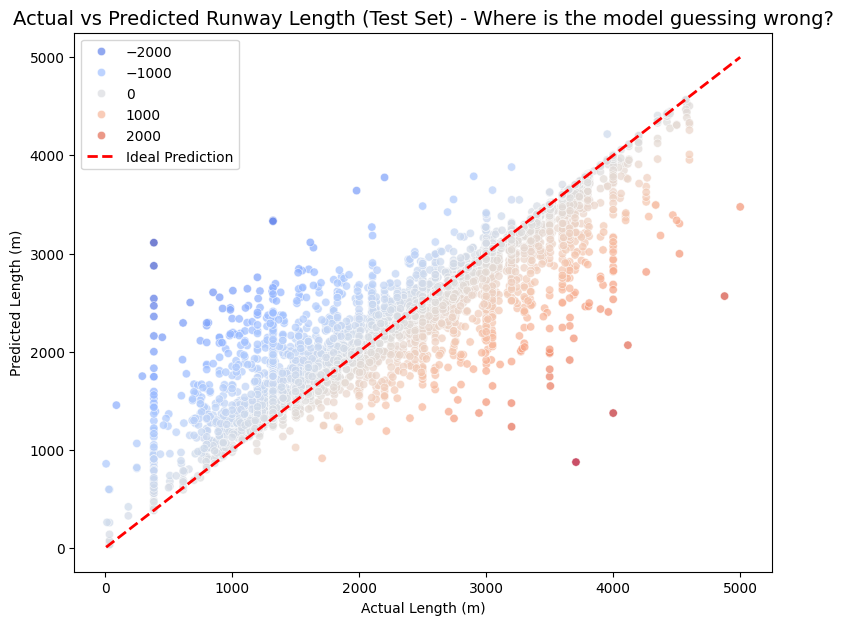

In [ ]:
#Taking a visual look at the Actual VS Predicted values
#to check where the model is guessing wrongly

y_rf_pred = rf.predict(X_test_scaled)

plt.figure(figsize=(9, 7))
#Plotting the predicted values (the answers given by the predictive model)
#Use the difference as the colour to see which points are way off
residuals = y_test - y_rf_pred
sns.scatterplot(x=y_test, y=y_rf_pred, hue=residuals, palette='coolwarm', alpha=0.7)

#Making the 'identity line', which shows if predicted = actual perfectly
#Takes the min and max of the y test results
#to draw a straight line through each other
#this is the 'answer sheet', 'perfect score' values
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='red', linestyle='--', lw=2, label='Ideal Prediction')

plt.title('Actual vs Predicted Runway Length (Test Set) - Where is the model guessing wrong?', fontsize=14)
plt.xlabel('Actual Length (m)')
plt.ylabel('Predicted Length (m)')
plt.legend()
plt.show()

This graph shows that most of the points following the red line. The R square value of ~83% means that the model is able to explain 83% of the reasons as to why runway lenghts differ, as per the features of the model. The remaining ~17% are due to factors that the model does not know about (since they are not in the data set), for eg local airport budgets, specific airline budgets, land space restrictions etc

In such geospatial and social science studies (like this capstone is), a score above 0.5 is considered good, and above 0.7 is considered as exceptional.
The gap between training and testing is 14%, which means that the model may be overftting.

In [ ]:
#Feature Importance

#One of the key advantages of using Random Forest is to be able to understand
#how much importance each feature takes up in trying to explain the target variable

C:\Users\chery\AppData\Local\Temp\ipykernel_20216\3305150139.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


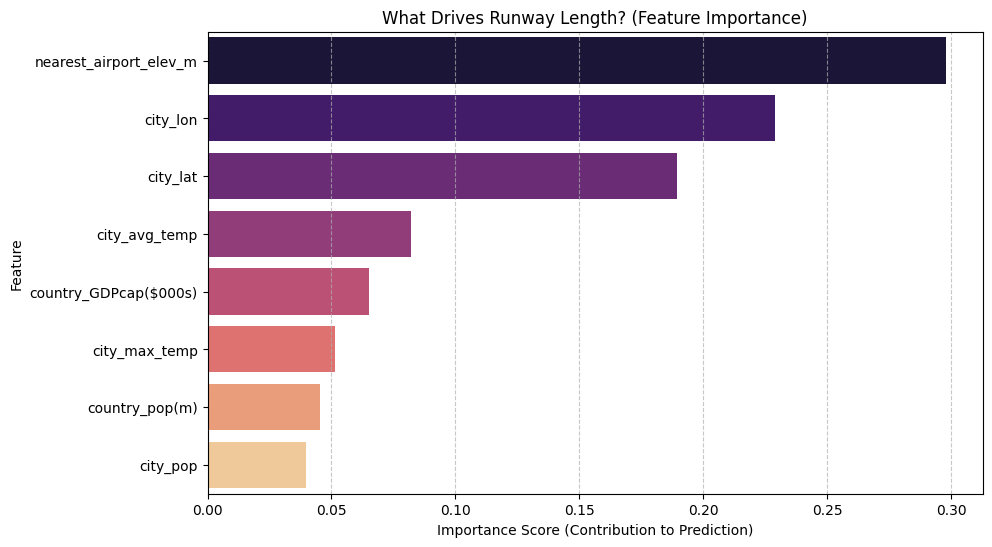

In [ ]:
#Extract importances from your final_rf model
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

#Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')

plt.title('What Drives Runway Length? (Feature Importance)')
plt.xlabel('Importance Score (Contribution to Prediction)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
feature_importance_df

,Feature,Importance
5,nearest_airport_elev_m,0.227825
0,city_lon,0.208001
1,city_lat,0.199433
7,city_avg_temp,0.105911
3,city_max_temp,0.076101
6,country_GDPcap($000s),0.075025
2,country_pop(m),0.060798
4,city_pop,0.046906


Feature Importance captures the interactions between the different features of the dataset, to try and predict runway lengths. This shows that amongst the 8 features, these are the percentages of importance as a whole (adding up to 100%).
In summary, we can see that:
1. Physical factors are key drivers of runway length - elevation, latitude and longitude, temperatures
2. GDP per capita is the next most important
3. Finally, population volumes are the third most important

In [ ]:
#Making a dataframe for the predicted y values for PowerBI interactive dashboard

#Take a copy of the original, unscaled data
powerbi_df = X_test.copy()

#Add actual Runway Lengths
powerbi_df['actual_runway_length'] = y_test

#Add predicted Runway Lengths from the RF model (chosen)
powerbi_df['predicted_runway_length'] = y_rf_pred

#Add the Error (Residual) for each row
#This shows where the model struggled to predict well
powerbi_df['prediction_error'] = powerbi_df['actual_runway_length'] - powerbi_df['predicted_runway_length']

In [ ]:
powerbi_df.to_csv('runway_predictions_for_powerbi.csv', index=False)